In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

1 Recommendation Analysis


In [ ]:
df = pd.read_csv("/content/spotify.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  object 
 1   artist_name       232725 non-null  object 
 2   track_name        232724 non-null  object 
 3   track_id          232725 non-null  object 
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   energy            232725 non-null  float64
 8   instrumentalness  232725 non-null  float64
 9   liveness          232725 non-null  float64
 10  loudness          232725 non-null  float64
 11  speechiness       232725 non-null  float64
 12  tempo             232725 non-null  float64
 13  valence           232725 non-null  float64
dtypes: float64(9), int64(1), object(4)
memory usage: 24.9+ MB


In [ ]:
features = ["danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo"]

In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[features])

In [ ]:
sample_size = 5000
df_sample = df.sample(n=sample_size, random_state=42).reset_index(drop=True)

# Scale the features for the sample using the previously initialized scaler
scaled_features_sample = scaler.fit_transform(df_sample[features])

# Now, compute the similarity matrix for the sample
similarity_matrix_sample = cosine_similarity(scaled_features_sample)

print(f"Shape of df_sample: {df_sample.shape}")
print(f"Shape of scaled_features_sample: {scaled_features_sample.shape}")
print(f"Shape of similarity_matrix_sample: {similarity_matrix_sample.shape}")

Shape of df_sample: (5000, 14)
Shape of scaled_features_sample: (5000, 9)
Shape of similarity_matrix_sample: (5000, 5000)


In [ ]:
similarity_matrix_sample = cosine_similarity(scaled_features_sample)

In [ ]:
similar_songs = similarity_matrix_sample[song_index].argsort()[-6:-1]

Display Recommendations


In [ ]:
recommendations = df.iloc[similar_songs][['track_name']]
print("Recommended Songs:")
print(recommendations)

Recommended Songs:
                             track_name
1821  Hand in My Pocket - 2015 Remaster
3113                   He Knows My Name
1985            Prisoner Of The Highway
654                         Why Georgia
3519                        Sharp Edges


2 Trend Visualization


In [ ]:
genre_trend = df.groupby('genre')['popularity'].mean()

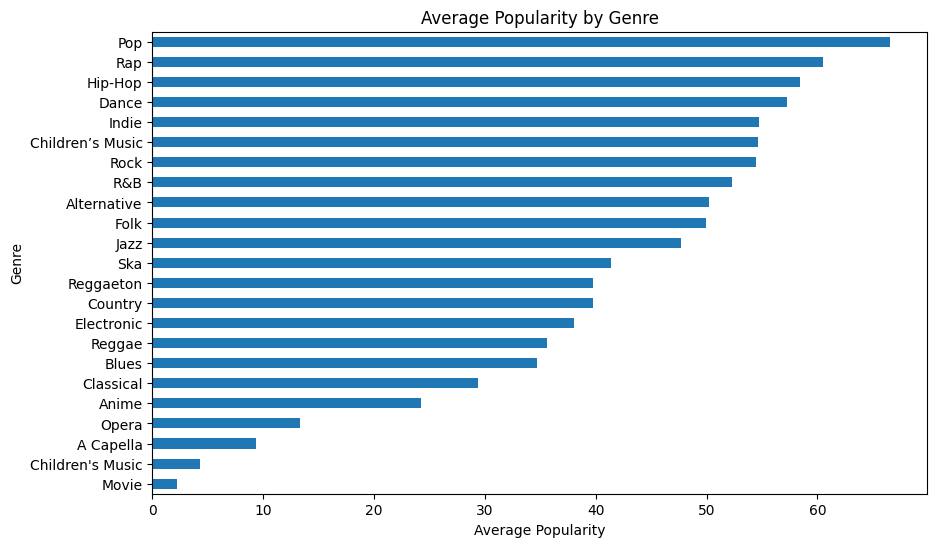

In [ ]:
plt.figure(figsize=(10,6))
genre_trend.sort_values().plot(kind='barh')

plt.title("Average Popularity by Genre")
plt.xlabel("Average Popularity")
plt.ylabel("Genre")

plt.show()

Audio Feature Analysis

In [ ]:
audio_features = ["danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo"]

In [ ]:
correlation = df[audio_features].corr()

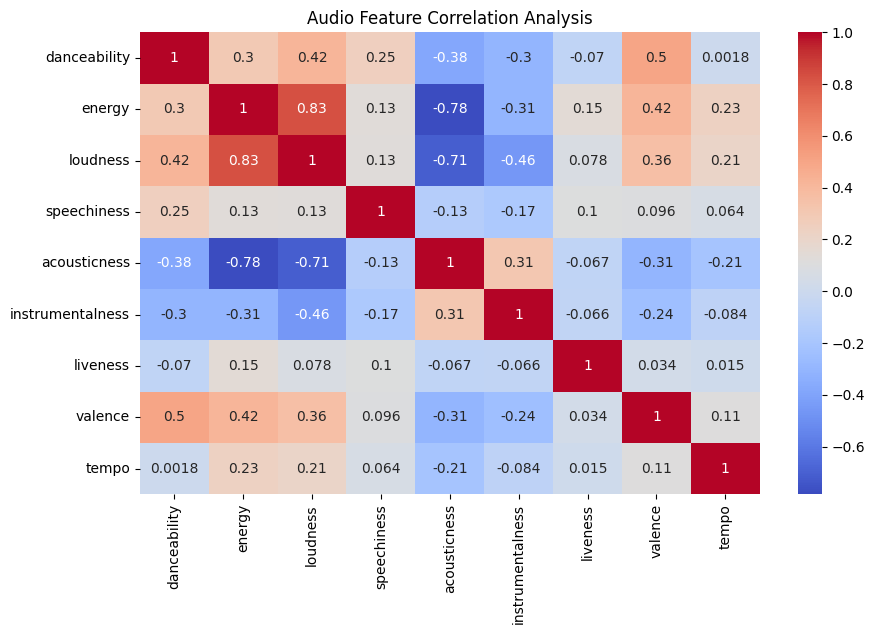

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("Audio Feature Correlation Analysis")
plt.show()